Example Plots for Simulated Annealing performed on IEEE57 (with currently 4 generators)

In [62]:
brute_force_data_paths = [
    'data/brute_force/candidate_space_256_instances_2026-03-14_15-30-37.csv',
    'data/brute_force/candidate_space_1048576_instances_2026-03-27_15-58-41.csv'
]
boundss = [
    [(0, 4)] * 4,
    [(0, 4)] * 10
]

In [63]:
import pandas as pd

brute_force_data = [pd.read_csv(p) for p in brute_force_data_paths]

In [64]:
from cl_optimizer import SimulatedAnnealing

# I think init and end temperatures should be chosen dependent on the delta of the energy,
# i.e. delta = new_loss - old_loss (in the exponent)
# larger delta -> larger temperature (and conversely smaller beta)
init_temp = 100
end_temp = 1
max_temp_iterations = 80

def execute_sim_ann(data: pd.DataFrame, bounds: list[tuple[int, int]]) -> list[float]:
    sim_ann = SimulatedAnnealing(
        lookup_table=data,
        bounds=bounds,
    )
    optima = []
    for iterations in range(1, max_temp_iterations + 1):
        print(f"Temp. Iterations {iterations}")
        temp_schedule = SimulatedAnnealing.geometric_temp_schedule(init_temp, end_temp, iterations)
        _, loss = sim_ann.optimize(
            temp_schedule=temp_schedule,
            verbose=False
        )
        optima.append(loss)

    return optima

In [71]:
from joblib import Parallel, delayed
import numpy as np

results = np.array(
    Parallel(n_jobs=len(brute_force_data), verbose=11)
    (delayed(execute_sim_ann)(data, bounds) for data, bounds in zip(brute_force_data, boundss))
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:    2.5s
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:  3.4min finished


In [53]:
min_loss = np.array([data['loss'].min() for data in brute_force_data])
max_loss = np.array([data['loss'].max() for data in brute_force_data])
approximation_ratios = (1 - (results.T - min_loss) / (max_loss - min_loss)).mean(axis=1)

In [54]:
approximation_ratios.shape

(80,)

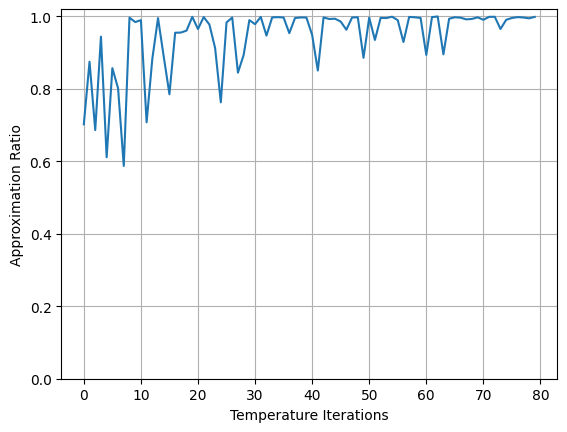

In [61]:
from matplotlib import pyplot as plt

plt.plot(
    range(results.shape[1]),
    approximation_ratios
)
plt.ylim([0, 1.02])
plt.ylabel('Approximation Ratio')
plt.xlabel('Temperature Iterations')
plt.grid(visible=True)